# 08 — Validation, Hyperparameters, Regularization, and Training Diagnostics (Manual NumPy)


> **Learning contract.** Every code cell is preceded by an explanation of what the code does, why the operation exists mathematically, what tensor/array shapes are expected, and what production or business failure it prevents. Run the notebooks in numerical order in a fresh Conda environment.


Validation is where development decisions are made. Hyperparameters include learning rate, batch size, hidden width, depth, activation, optimizer, initialization, regularization strength and epoch budget. The validation set estimates how these choices generalize without contaminating the final test.

### Diagnostic patterns
- high train + high validation error → underfitting or optimization failure
- low train error + worsening validation error → overfitting
- noisy/diverging loss → learning rate or numerical instability
- flat gradients → saturation/dead units/graph bug
- exploding norms → unstable scale or optimizer


## Code walkthrough — inspect the persisted training history
We deliberately keep this notebook diagnostic: it interprets evidence rather than performing hidden model-selection on the test set. A production tuning system would compare multiple runs using validation metrics and only promote the chosen configuration to final test.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / "mnist.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"


def load_official_mnist():
    if not MNIST_PATH.exists():
        print("Downloading official MNIST archive to", MNIST_PATH)
        urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
    with np.load(MNIST_PATH) as data:
        return (data["x_train"], data["y_train"], data["x_test"], data["y_test"])


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    selected = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        selected.extend(rng.choice(candidates, size=per_class, replace=False))
    selected = np.asarray(selected)
    rng.shuffle(selected)
    return (x[selected], y[selected])


def prepare_splits():
    x_train_raw, y_train_raw, x_test_raw, y_test_raw = load_official_mnist()
    x_dev, y_dev = balanced_subset(x_train_raw, y_train_raw, per_class=600)
    x_test, y_test = balanced_subset(
        x_test_raw, y_test_raw, per_class=100, seed=SEED + 1
    )
    x_train, x_val, y_train, y_val = train_test_split(
        x_dev, y_dev, test_size=1000, random_state=SEED, stratify=y_dev
    )

    def transform(x):
        return x.reshape(len(x), -1).astype("float32") / 255.0

    return (
        transform(x_train),
        y_train,
        transform(x_val),
        y_val,
        transform(x_test),
        y_test,
    )


rng = np.random.default_rng(SEED)
W1 = rng.normal(0, np.sqrt(2 / 784), size=(784, 64)).astype("float32")
b1 = np.zeros((1, 64), dtype="float32")
W2 = rng.normal(0, np.sqrt(2 / 64), size=(64, 10)).astype("float32")
b2 = np.zeros((1, 10), dtype="float32")


def relu(z):
    return np.maximum(z, 0)


def softmax(z):
    shifted = z - z.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)


def forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    logits = a1 @ W2 + b2
    return (z1, a1, logits)


X_train, y_train, X_val, y_val, X_test, y_test = prepare_splits()
print(
    "Manual diagnostics: compare training/validation curves above; very large learning rates can make loss oscillate. Weight norms:",
    np.linalg.norm(W1),
    np.linalg.norm(W2),
)

Manual diagnostics: compare training/validation curves above; very large learning rates can make loss oscillate. Weight norms: 11.34363 4.3929834


## Code walkthrough — visualize a canonical overfit/underfit mental model
These synthetic curves are explanatory, not model results. They provide a visual vocabulary for interpreting real training histories.


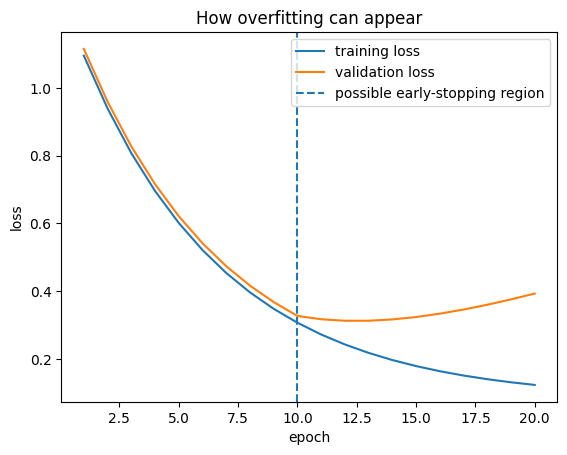

In [2]:
epochs = np.arange(1, 21)
train = 1.2 * np.exp(-epochs / 6) + 0.08
val = train + 0.02 + np.maximum(epochs - 10, 0) * 0.025
plt.plot(epochs, train, label="training loss")
plt.plot(epochs, val, label="validation loss")
plt.axvline(10, ls="--", label="possible early-stopping region")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("How overfitting can appear")
plt.show()

## Code walkthrough — make an actual hyperparameter decision using validation only
To keep the experiment fast and isolate the role of validation, this cell trains the same small NumPy softmax classifier under three learning rates. We do **not** inspect test accuracy. The point is methodological: choose configuration from validation evidence, then freeze the choice before final test.


lr 0.01 final validation accuracy 0.341
lr 0.1 final validation accuracy 0.787
lr 0.8 final validation accuracy 0.712


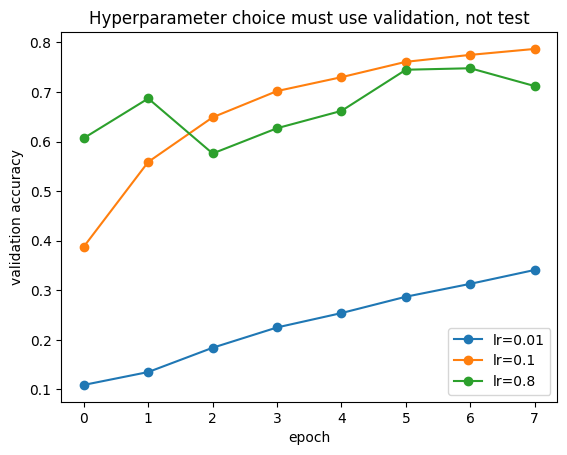

In [3]:
Xtr, ytr, Xv, yv, _, _ = prepare_splits()
Xtr = Xtr[:2500]
ytr = ytr[:2500]


def run_lr(lr, epochs=8):
    rng = np.random.default_rng(SEED)
    W = rng.normal(0, 0.01, size=(784, 10))
    b = np.zeros((1, 10))
    vals = []
    for _ in range(epochs):
        logits = Xtr @ W + b
        e = np.exp(logits - logits.max(1, keepdims=True))
        p = e / e.sum(1, keepdims=True)
        d = p
        d[np.arange(len(ytr)), ytr] -= 1
        d /= len(ytr)
        W -= lr * (Xtr.T @ d)
        b -= lr * d.sum(0, keepdims=True)
        vp = np.exp(Xv @ W + b - (Xv @ W + b).max(1, keepdims=True))
        vp /= vp.sum(1, keepdims=True)
        vals.append((vp.argmax(1) == yv).mean())
    return vals


results = {lr: run_lr(lr) for lr in [0.01, 0.1, 0.8]}
for lr, vals in results.items():
    print("lr", lr, "final validation accuracy", round(vals[-1], 4))
for lr, vals in results.items():
    plt.plot(vals, marker="o", label=f"lr={lr}")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Hyperparameter choice must use validation, not test")
plt.legend()
plt.show()

## Decision discipline
Once the best configuration is chosen using validation evidence, freeze it. Only then evaluate once on test. Repeatedly checking test while tuning converts test into another validation set and makes the reported performance optimistic.
